In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score


C:\Users\MYPC\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
df = pd.read_csv(
    r"C:\Users\MYPC\Desktop\Skin Cancer\HAM10000_metadata.csv"
)

IMAGE_DIR = r"C:\Users\MYPC\Desktop\Skin Cancer\HAM10000_images"

df["filename"] = df["image_id"].apply(
    lambda x: os.path.join(IMAGE_DIR, x + ".jpg")
)
df["filename"] = df["filename"].apply(lambda x: x.replace("\\", "/"))

# MEDICAL TARGET
df["target"] = (df["dx"] == "mel").astype(int)


In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(
    df["filename"].values,
    df["target"].values,
    test_size=0.3,
    random_state=42,
    stratify=df["target"]
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)


In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.map(load_image).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [7]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)
model.summary()



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)


In [9]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks
)


Epoch 1/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 250s 1s/step - accuracy: 0.8749 - auc: 0.6640 - loss: 0.3547 - val_accuracy: 0.8908 - val_auc: 0.7934 - val_loss: 0.2938
Epoch 2/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 235s 1s/step - accuracy: 0.8886 - auc: 0.7723 - loss: 0.2997 - val_accuracy: 0.8908 - val_auc: 0.8271 - val_loss: 0.2757
Epoch 3/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.8954 - auc: 0.8053 - loss: 0.2827 - val_accuracy: 0.8928 - val_auc: 0.8381 - val_loss: 0.2736
Epoch 4/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - accuracy: 0.8957 - auc: 0.8303 - loss: 0.2707 - val_accuracy: 0.8901 - val_auc: 0.8494 - val_loss: 0.2623
Epoch 5/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.8986 - auc: 0.8414 - loss: 0.2633 - val_accuracy: 0.8941 - val_auc: 0.8517 - val_loss: 0.2592
Epoch 6/25
220/220 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.8997 - auc: 0.8492 - loss: 0.2580 - val_accuracy: 0.8935 - val_auc: 0.8576 - val_loss: 0.2574
Epoch 7/25
220/220 ━━━━━━━━━━━━━━━

In [10]:
y_prob = model.predict(test_ds)

threshold = 0.4  # medical threshold
y_pred = (y_prob > threshold).astype(int)

from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test Recall  :", recall_score(y_test, y_pred))
print("Test AUC     :", roc_auc_score(y_test, y_prob))


47/47 ━━━━━━━━━━━━━━━━━━━━ 53s 955ms/step
Test Accuracy: 0.895542248835662
Test Recall  : 0.3772455089820359
Test AUC     : 0.8604602172899709


In [12]:
for t in [0.4, 0.35, 0.3, 0.25]:
    y_pred_t = (y_prob > t).astype(int)
    print(
        f"Threshold {t} | "
        f"Accuracy: {accuracy_score(y_test, y_pred_t):.3f} | "
        f"Recall: {recall_score(y_test, y_pred_t):.3f}"
    )


Threshold 0.4 | Accuracy: 0.896 | Recall: 0.377
Threshold 0.35 | Accuracy: 0.890 | Recall: 0.455
Threshold 0.3 | Accuracy: 0.878 | Recall: 0.479
Threshold 0.25 | Accuracy: 0.870 | Recall: 0.557


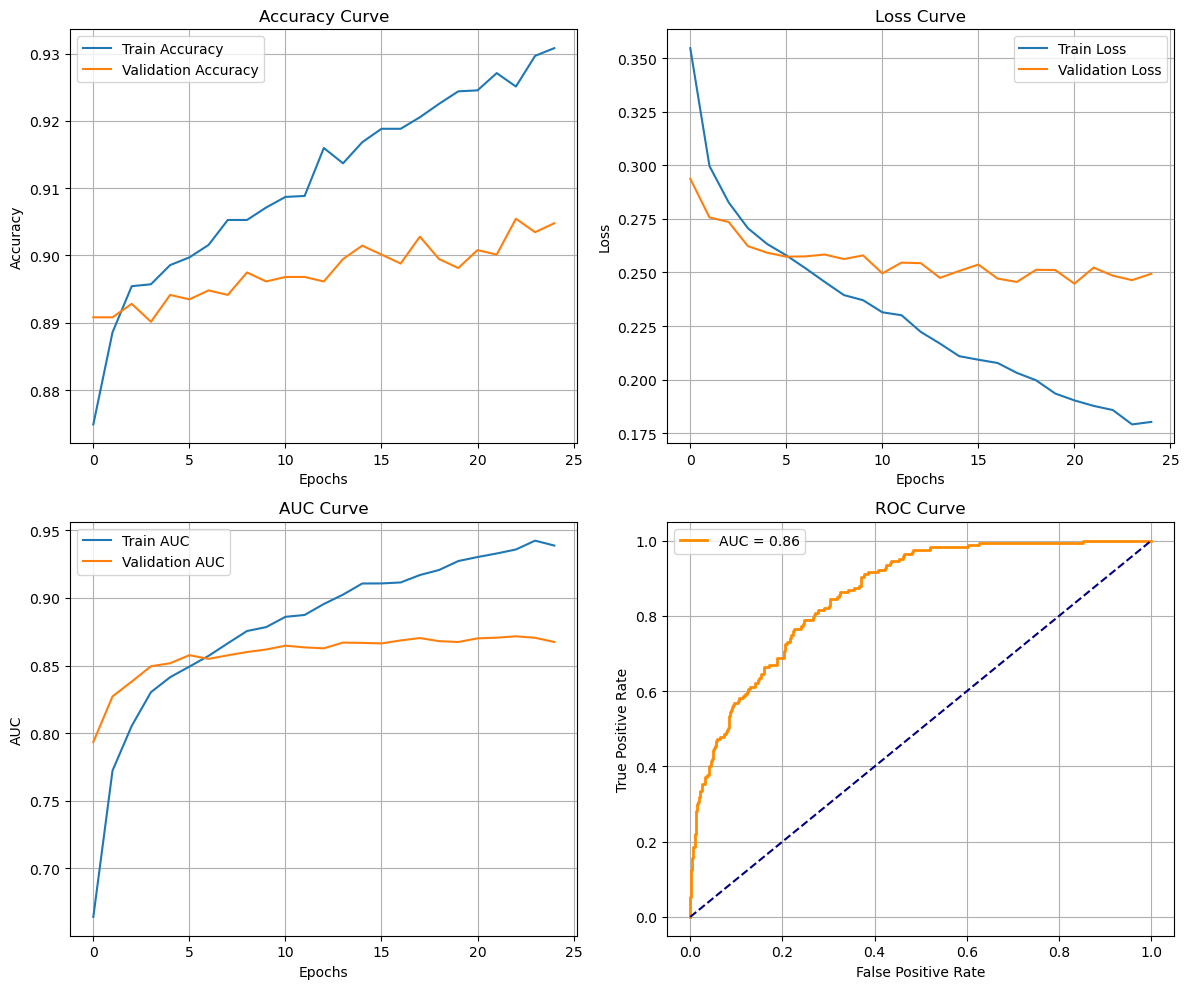

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ---------- CREATE FIGURE ----------
plt.figure(figsize=(12, 10))

# ===== 1️⃣ ACCURACY CURVE =====
plt.subplot(2, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# ===== 2️⃣ LOSS CURVE =====
plt.subplot(2, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# ===== 3️⃣ AUC CURVE =====
plt.subplot(2, 2, 3)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('AUC Curve')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)

# ===== 4️⃣ ROC CURVE =====
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.subplot(2, 2, 4)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='navy')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)

# ---------- SAVE & SHOW ----------
plt.tight_layout()
plt.savefig("all_medical_graphs.png", dpi=300)
plt.show()
